# Practical Exercise 2

## Question 1
Downloaded [Airplane crash data set](https://www.kaggle.com/datasets/saurograndi/airplane-crashes-since-1908/data) into the data dir

Import the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Setting up the data frame

In [2]:
df = pd.read_csv("data/Airplane_Crashes_and_Fatalities_Since_1908.csv")

## Question 2

Getting the shape of our data( Number of rows and columns)

In [3]:
rows, columns = df.shape
print(f"Number of rows: {rows}")
print(f"NUmber of columns: {columns}")

Number of rows: 5268
NUmber of columns: 13


## Question 3

Displaying the last 75 rows in the data set

In [4]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


## Question 4
Each column except the first one has some missing data. For each column, name
the most appropriate method for treating the missing data. Justify your choices.

The `Date` column does not contain missing values, so no treatment is required for this column. Each of the remaining columns contains some missing values, and the appropriate treatment depends on the type of data in each column.

| Column | Recommended Method | Justification |
|---|---|---|
| `Time` | Replace with `"Unknown"` | Time is a time-based value. There is no meaningful average time that can be used to replace an unknown accident time. |
| `Location` | Replace with `"Unknown"` | Location is categorical data. Using the most common location could introduce incorrect information. |
| `Operator` | Replace with `"Unknown"` | Operator is categorical data, so replacing a missing value with the most common operator could be misleading. |
| `Flight #` | Replace with `"Unknown"` | Flight numbers are identifiers, so statistical methods such as mean or median are not appropriate. |
| `Route` | Replace with `"Unknown"` | Route is categorical/text data and cannot reliably be inferred when it is missing. |
| `Type` | Replace with `"Unknown"` | Aircraft type is categorical data, so using the mode could incorrectly assign an aircraft type. |
| `Registration` | Replace with `"Unknown"` | Registration is an identifier, so numerical imputation would not be appropriate. |
| `cn/In` | Replace with `"Unknown"` | This is an aircraft construction/serial identifier, so it should not be statistically imputed. |
| `Aboard` | Replace with the median | This is numerical data. The median is less affected by unusually large or small numbers of people aboard. |
| `Fatalities` | Replace with the median | This is numerical count data and can contain extreme values. The median is more resistant to outliers than the mean. |
| `Ground` | Replace with the median | This is numerical data and may contain extreme values, making the median a suitable replacement. |
| `Summary` | Replace with `"No summary available"` | Summary is text data, so there is no meaningful numerical value that can be used to fill missing entries. |

## Question 5
Create a new dataframe from the raw/uncleaned data called `fatality_locations` with the following columns: `Date`, `Location`, `Aboard`, `Fatalities`

In [5]:
fatality_locations = df[["Date", "Location", "Aboard", "Fatalities"]]

## Question 6
Determine the date of the highest number of recorded fatalities from this new
dataframe.

In [6]:
date_of_highets_fatalities = fatality_locations.loc[fatality_locations['Fatalities'].idxmax(), 'Date']
print(f"Highest number of fatalities was on {date_of_highets_fatalities}")

Highest number of fatalities was on 03/27/1977


## Question 7
Compare the number of passengers aboard to the number of fatalities per crash. Are
there any recorded crashes where there were no fatalities? If so, how many?

In [7]:
# Comparision
fatality_locations[['Aboard', 'Fatalities']]

,Aboard,Fatalities
0,2.0,1.0
1,5.0,5.0
2,1.0,1.0
3,20.0,14.0
4,30.0,30.0
...,...,...
5263,112.0,98.0
5264,4.0,4.0
5265,228.0,228.0
5266,1.0,1.0


In [8]:
# Number of crashes where there were no fatalities
num = (fatality_locations['Fatalities'] == 0).sum()
print(f"Number of crashes where there are no fatalities: {num}")

Number of crashes where there are no fatalities: 58


## Question 8
In the `fatality_locations` dataframe, the location column has data items represented as ‘Region, U.S. State/Country’. Split this column to have two columns of regions and states/countries.

In [9]:
fatality_locations[['Region', 'State/Country']] = (
    fatality_locations['Location'].str.split(',', n=1, expand=True)
)
fatality_locations.head()

,Date,Location,Aboard,Fatalities,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,Victoria,"British Columbia, Canada"
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,NaN
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany


## Question 9
Order the dataframe by the number of fatalities from highest to lowest and select the first 100.

In [10]:
top_100_fatalities = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)
top_100_fatalities

,Date,Location,Aboard,Fatalities,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,Mt. Osutaka,"near Ueno Village, Japan"
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,Elburz Mtns.,"near Laskarak, Markazi, Iran"
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


## Question 10
Generate a pie chart that shows the distribution of the top 25 number of fatalities per country/U.S. State. 

State/Country
Canary Islands                          583.0
Saudi Arabia                            562.0
near Ueno Village, Japan                520.0
India                                   349.0
France                                  346.0
110 miles West of Ireland               329.0
near Bandar Abbas, Iran                 290.0
Iran                                    275.0
Illinois                                271.0
Russia                                  269.0
Aichi, Japan                            264.0
Queens, New York                        260.0
Scotland                                259.0
Ross Ice Shelf, Antarctica              257.0
Newfoundland, Canada                    256.0
Afghanistan                             240.0
Indonesia                               234.0
New York                                230.0
Nova Scotia, Canada                     229.0
Guam                                    229.0
570 miles northeast of Natal, Brazil    228.0
Taiwan              

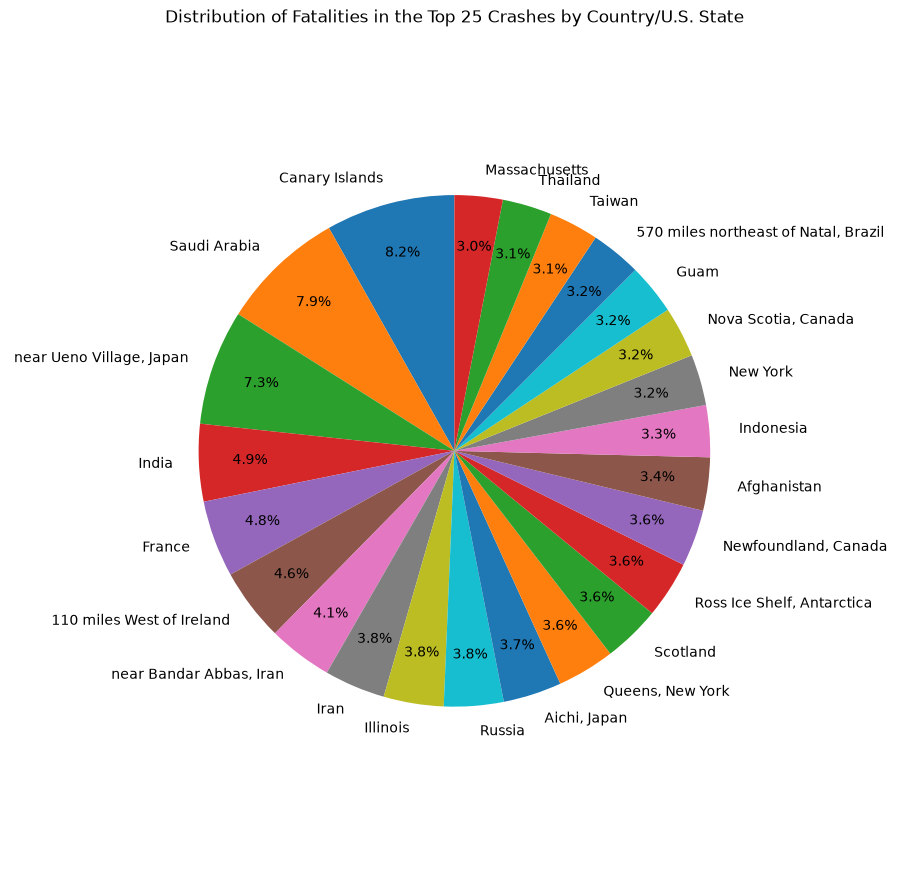

In [11]:
top_25_fatalities = top_100_fatalities.head(25)

# Grouping them 
fatalities_by_region = (
    top_25_fatalities.groupby('State/Country')['Fatalities']
    .sum()
    .sort_values(ascending=False)
)
print(fatalities_by_region)

# The pie chart using matplotlib
plt.figure(figsize=(9, 9))
plt.pie(
    fatalities_by_region,
    labels=fatalities_by_region.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8
)
plt.title('Distribution of Fatalities in the Top 25 Crashes by Country/U.S. State')
plt.axis('equal')
plt.tight_layout()
plt.show()